# CeNNMixer-v1 for Qwen3.5-0.8B
## Replace DeltaNet / Attention, keep embedding + FFN

This Colab tests a new **multi-timescale cellular recurrent sequence mixer** as a drop-in replacement for Qwen3.5 token mixers.

The first experiment should replace one layer only:

    layer 0: Gated DeltaNet -> CeNNMixer-v1

Once it preserves Qwen well, test progressively:

    0
    0,1
    0,1,2
    0,1,2,3
    ...

Qwen embedding, RMSNorm, FFN and LM head remain frozen and unchanged.

CeNNMixer-v1 contains:
- 16 grouped cellular neighborhoods
- fast / medium / slow recurrent state
- sparse neighbor exchange ±1 ±2 ±4 ±8
- separate erase / write / read gates
- no softmax attention
- no DeltaNet matrix state
- fixed-size recurrent state for streaming decoding


In [1]:
#@title 1. Setup
import pathlib, subprocess, sys, importlib, json, torch, os, time

REPO_DIR=pathlib.Path('/content/TinyCeNN-LM')
if REPO_DIR.exists():
    subprocess.run(['git','-C',str(REPO_DIR),'fetch','origin'],check=True)
    subprocess.run(['git','-C',str(REPO_DIR),'reset','--hard','origin/main'],check=True)
else:
    subprocess.run(['git','clone','https://github.com/vtavakkoli/TinyCeNN-LM.git',str(REPO_DIR)],check=True)

subprocess.run([
    sys.executable,'-m','pip','install','-q','-U',
    'transformers','accelerate','datasets','pandas','matplotlib','huggingface_hub'
],check=True)
subprocess.run([sys.executable,'-m','pip','install','-q','-e',str(REPO_DIR)],check=True)

SRC=REPO_DIR/'src'
if str(SRC) not in sys.path: sys.path.insert(0,str(SRC))
for n in list(sys.modules):
    if n=='tinycenn_lm' or n.startswith('tinycenn_lm.'):
        del sys.modules[n]
importlib.invalidate_caches()

for p in [
    REPO_DIR/'src'/'tinycenn_lm'/'qwen35_cennmixer_v1.py',
    REPO_DIR/'scripts'/'run_qwen35_cennmixer_v1.py'
]:
    subprocess.run([sys.executable,'-m','py_compile',str(p)],check=True)

print('✓ CeNNMixer-v1 preflight OK')
print('CUDA:',torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:',torch.cuda.get_device_name(0))
else:
    print('⚠️ Switch Colab to a GPU runtime.')


✓ CeNNMixer-v1 preflight OK
CUDA: True
GPU: Tesla T4


In [4]:
#@title 2. Experiment configuration
BASE_MODEL='Qwen/Qwen3.5-0.8B' #@param {type:'string'}

# Start with "0". Later test "0,1", then "0,1,2", etc.
LAYERS='0' #@param {type:'string'}

SEQ_LEN=128 #@param {type:'integer'}
TRAIN_BLOCKS=512 #@param {type:'integer'}
VAL_BLOCKS=32 #@param {type:'integer'}

MAX_UPDATES=10000 #@param {type:'integer'}
PROBE_EVERY=50 #@param {type:'integer'}
LR=0.001 #@param {type:'number'}

GROUPS=16 #@param {type:'integer'}
CELL_DIM=32 #@param {type:'integer'}
GRAPH_STEPS=1 #@param {type:'integer'}

MIN_TOP1=0.97 #@param {type:'number'}
MAX_KL=0.03 #@param {type:'number'}
MAX_HIDDEN_MSE=0.03 #@param {type:'number'}

OUTPUT_DIR=REPO_DIR/'results'/'cennmixer_v1_qwen35_08b'

print('Replacing layer(s):',LAYERS)
print('CeNN state/group:',CELL_DIM,'groups:',GROUPS)
print('Total state dimensions per timescale:',GROUPS*CELL_DIM)
print('Three timescales total recurrent state:',3*GROUPS*CELL_DIM)


Replacing layer(s): 0
CeNN state/group: 32 groups: 16
Total state dimensions per timescale: 512
Three timescales total recurrent state: 1536


In [5]:
#@title 3. Run CeNN distillation
cmd=[
    sys.executable,'-u',str(REPO_DIR/'scripts'/'run_qwen35_cennmixer_v1.py'),
    '--base-model',BASE_MODEL,
    '--layers',LAYERS,
    '--seq-len',str(SEQ_LEN),
    '--train-blocks',str(TRAIN_BLOCKS),
    '--val-blocks',str(VAL_BLOCKS),
    '--max-updates',str(MAX_UPDATES),
    '--probe-every',str(PROBE_EVERY),
    '--lr',str(LR),
    '--groups',str(GROUPS),
    '--cell-dim',str(CELL_DIM),
    '--graph-steps',str(GRAPH_STEPS),
    '--min-top1',str(MIN_TOP1),
    '--max-kl',str(MAX_KL),
    '--max-hidden-mse',str(MAX_HIDDEN_MSE),
    '--output-dir',str(OUTPUT_DIR)
]

print('='*110)
print(' '.join(cmd))
print('='*110)

p=subprocess.Popen(cmd,stdout=subprocess.PIPE,stderr=subprocess.STDOUT,text=True,bufsize=1)
for line in iter(p.stdout.readline,''):
    print(line,end='',flush=True)
rc=p.wait()
print('\nFinished, exit code',rc)
if rc:
    raise subprocess.CalledProcessError(rc,cmd)


/usr/bin/python3 -u /content/TinyCeNN-LM/scripts/run_qwen35_cennmixer_v1.py --base-model Qwen/Qwen3.5-0.8B --layers 0 --seq-len 128 --train-blocks 512 --val-blocks 32 --max-updates 10000 --probe-every 50 --lr 0.001 --groups 16 --cell-dim 32 --graph-steps 1 --min-top1 0.97 --max-kl 0.03 --max-hidden-mse 0.03 --output-dir /content/TinyCeNN-LM/results/cennmixer_v1_qwen35_08b
DEVICE cuda dtype torch.bfloat16 layers [0]

Loading weights: 100%|██████████| 320/320 [00:00<00:00, 3943.39it/s]

Loading weights: 100%|██████████| 320/320 [00:00<00:00, 4413.87it/s]

Generating test split: 100%|██████████| 4358/4358 [00:00<00:00, 136364.01 examples/s]

Generating train split: 100%|██████████| 36718/36718 [00:00<00:00, 822060.48 examples/s]

Generating validation split: 100%|██████████| 3760/3760 [00:00<00:00, 638873.12 examples/s]
[transformers] `causal_conv1d_fn` is falling back to its reference PyTorch implementation because `causal_conv1d` is not installed. This is correct but much slower; instal

In [6]:
#@title 4. Results
import pandas as pd
from IPython.display import display

report=json.loads((OUTPUT_DIR/'report.json').read_text())
hist=pd.read_csv(OUTPUT_DIR/'training_history.csv')

print('Layers:',report['layers'])
print('Original mixer types:',report['layer_kinds'])
print('Best step:',report['best_step'])
print('Quality gate:',report['quality_gate'])
print('\nInitial:')
print(json.dumps(report['initial'],indent=2))
print('\nBest/final:')
print(json.dumps(report['final'],indent=2))
print('\nParameter comparison:')
print('CeNN params:',f"{report['cenn_trainable_params']:,}")
print('Qwen mixer params replaced:',f"{report['replaced_qwen_mixer_params']:,}")
print('Mixer parameter reduction:',f"{report['mixer_param_reduction_pct']:.2f}%")

display(hist)


Layers: [0]
Original mixer types: {'0': 'linear_attention'}
Best step: 10000
Quality gate: False

Initial:
{
  "teacher_ce": 3.7534333020448685,
  "student_ce": 11.306486964225769,
  "kl": 7.625322535634041,
  "hidden_mse": 2.0675793141126633,
  "delta_mse": 2.186657078564167,
  "ce_gap": 7.553053662180901,
  "top1": 0.00537109375
}

Best/final:
{
  "teacher_ce": 3.7534333020448685,
  "student_ce": 3.8894392549991608,
  "kl": 0.3067382201552391,
  "hidden_mse": 0.2767185573466122,
  "delta_mse": 0.33854146860539913,
  "ce_gap": 0.1360059529542923,
  "top1": 0.744873046875
}

Parameter comparison:
CeNN params: 2,247,840
Qwen mixer params replaced: 10,543,264
Mixer parameter reduction: 78.68%


,step,train_loss,teacher_ce,student_ce,kl,hidden_mse,delta_mse,ce_gap,top1
0,1,4.127550,3.753433,11.308327,7.625821,2.067584,2.186615,7.554894,0.005615
1,50,2.977417,3.753433,9.329863,5.694945,1.525124,1.338207,5.576429,0.044434
2,100,3.180004,3.753433,9.295337,5.639197,1.303902,1.355948,5.541904,0.041016
3,150,2.855462,3.753433,8.987795,5.384129,1.247648,1.310383,5.234362,0.042969
4,200,2.904157,3.753433,8.613795,4.987783,1.268842,1.273550,4.860361,0.067139
...,...,...,...,...,...,...,...,...,...
196,9800,0.526548,3.753433,3.891318,0.304729,0.279625,0.341623,0.137885,0.742676
197,9850,0.516567,3.753433,3.910061,0.315775,0.281002,0.344611,0.156628,0.738281
198,9900,0.545536,3.753433,3.901748,0.304767,0.277107,0.340363,0.148315,0.736816
199,9950,0.636426,3.753433,3.891598,0.314869,0.278296,0.341450,0.138165,0.730957


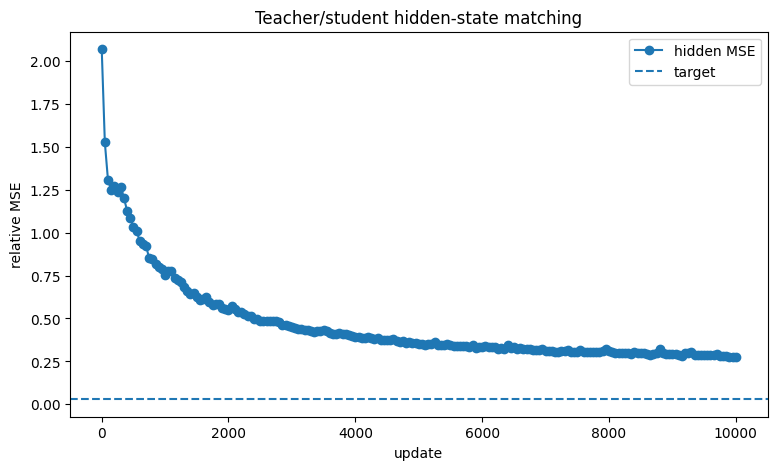

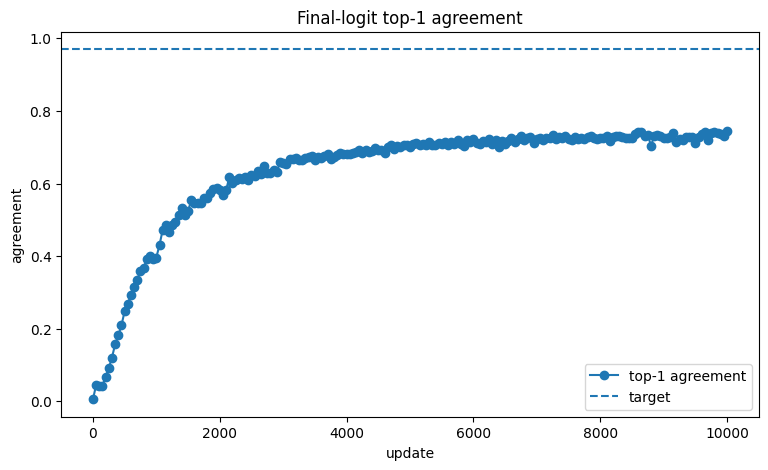

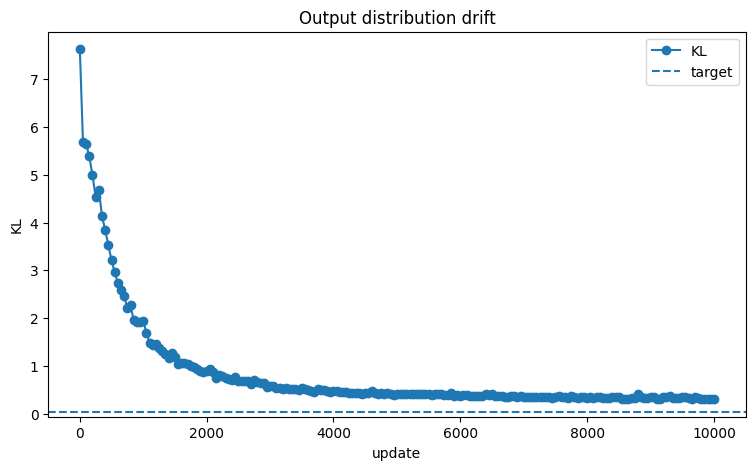

In [7]:
#@title 5. Convergence plots
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))
plt.plot(hist['step'],hist['hidden_mse'],marker='o',label='hidden MSE')
plt.axhline(MAX_HIDDEN_MSE,linestyle='--',label='target')
plt.xlabel('update')
plt.ylabel('relative MSE')
plt.title('Teacher/student hidden-state matching')
plt.legend()
plt.show()

plt.figure(figsize=(9,5))
plt.plot(hist['step'],hist['top1'],marker='o',label='top-1 agreement')
plt.axhline(MIN_TOP1,linestyle='--',label='target')
plt.xlabel('update')
plt.ylabel('agreement')
plt.title('Final-logit top-1 agreement')
plt.legend()
plt.show()

plt.figure(figsize=(9,5))
plt.plot(hist['step'],hist['kl'],marker='o',label='KL')
plt.axhline(MAX_KL,linestyle='--',label='target')
plt.xlabel('update')
plt.ylabel('KL')
plt.title('Output distribution drift')
plt.legend()
plt.show()


In [8]:
#@title 6. Generation comparison
for i,x in enumerate(report['generation'],1):
    print('\n'+'='*100)
    print(i,'USER:',x['prompt'])
    print('\nQWEN:',x['qwen'])
    print('\nCeNN:',x['cenn'])
    print('\nexact=',x['exact'],'| jaccard=',round(x['jaccard'],3))



1 USER: What is 17 + 25? Give only the answer.

QWEN: 42

CeNN: .

.

.

.

.

.

.

.

.

.

.

.

.

.

.

.

.

.

.

.

.

.

.

.

exact= False | jaccard= 0.0

2 USER: Write one short sentence about Vienna.

QWEN: Vienna is a historic city known for its rich culture, vibrant nightlife, and stunning architecture.

CeNN: .

.
. . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .

exact= False | jaccard= 0.087

3 USER: Explain in one sentence what an API is.

QWEN: An API is a set of rules and protocols that allows software applications to communicate with each other.

CeNN: .

.

.

.

.

.

.

.

.

.

.

.

.

.

.

.

.

.

.

.

.

.

.

.

exact= False | jaccard= 0.043

4 USER: The secret number is 81427. Remember it. What is the secret number? Give only the number.

QWEN: 81427

CeNN: The secret number is 81427. Remember it. What is the secret number? Give only the number.

.
.
. . . . . . . . . . . . . . . .

exact= False | jaccard= 0.273


## How to proceed

A single replaced layer is a success only when all three signals are good together:

- hidden-state relative MSE stays low,
- final logit top-1 agreement stays high,
- KL remains low,
- generation remains coherent.

Do **not** jump directly to all 24 layers.

Recommended progression:

    LAYERS="0"
    then "0,1"
    then "0,1,2"
    then "0,1,2,3"

Layer 3 is especially interesting because it is the first full-attention block in the 3:1 Qwen3.5 hybrid pattern.

If layer 0 cannot be matched, tune CeNN capacity before replacing more layers:
- CELL_DIM 32 -> 48 -> 64
- GROUPS 16 -> 32
- GRAPH_STEPS 1 -> 2
- MAX_UPDATES 1000 -> 3000

Once a stable configuration is found, the next version should automate progressive replacement across all 24 sequence-mixer layers while always restoring the best checkpoint from the previous replacement stage.


In [9]:
#@title 7. Save best CeNNMixer-v1 checkpoint to Hugging Face
from huggingface_hub import HfApi, notebook_login
import pathlib, json, shutil, torch

HF_REPO_ID='vtava/Qwen35-0.8B-CeNNMixer-v1' #@param {type:'string'}
HF_PRIVATE=False #@param {type:'boolean'}

HF_EXPORT_DIR=REPO_DIR/'results'/'Qwen35-0.8B-CeNNMixer-v1-HF'
if HF_EXPORT_DIR.exists():
    shutil.rmtree(HF_EXPORT_DIR)
HF_EXPORT_DIR.mkdir(parents=True,exist_ok=True)

report=json.loads((OUTPUT_DIR/'report.json').read_text())
best_ckpt=torch.load(OUTPUT_DIR/'cennmixer_v1_best.pt',map_location='cpu')

# Save CeNN adapter checkpoint + metadata.
torch.save(best_ckpt,HF_EXPORT_DIR/'cennmixer_v1_best.pt')
shutil.copy2(OUTPUT_DIR/'report.json',HF_EXPORT_DIR/'report.json')
if (OUTPUT_DIR/'training_history.csv').exists():
    shutil.copy2(OUTPUT_DIR/'training_history.csv',HF_EXPORT_DIR/'training_history.csv')

config={
    'base_model':BASE_MODEL,
    'architecture':'CeNNMixer-v1',
    'layers':report['layers'],
    'layer_kinds':report['layer_kinds'],
    'cenn_config':report['config'],
    'best_step':report['best_step'],
    'quality_gate':report['quality_gate'],
}
(HF_EXPORT_DIR/'cennmixer_config.json').write_text(json.dumps(config,indent=2),encoding='utf-8')

readme=f"""---
base_model: {BASE_MODEL}
library_name: transformers
pipeline_tag: text-generation
tags:
- qwen
- cenn
- recurrent
- sequence-mixer
- tinycenn
---

# Qwen3.5-0.8B CeNNMixer-v1

Experimental CeNN sequence-mixer replacement for Qwen3.5-0.8B.

## Replaced layers

{report['layers']}

Original mixer types:

{json.dumps(report['layer_kinds'],indent=2)}

## Best checkpoint

- Best step: {report['best_step']}
- Quality gate: {report['quality_gate']}
- Top-1 agreement: {report['final']['top1']:.6f}
- KL vs Qwen: {report['final']['kl']:.6f}
- Hidden-state relative MSE: {report['final']['hidden_mse']:.6f}
- Student validation CE: {report['final']['student_ce']:.6f}
- Qwen validation CE: {report['final']['teacher_ce']:.6f}

## Parameter comparison

- CeNN parameters: {report['cenn_trainable_params']:,}
- Replaced Qwen mixer parameters: {report['replaced_qwen_mixer_params']:,}
- Mixer parameter reduction: {report['mixer_param_reduction_pct']:.2f}%

## Architecture

CeNNMixer-v1 uses:
- grouped cellular recurrent state
- fast / medium / slow memory timescales
- sparse neighbor communication
- separate erase / write / read gates
- no softmax attention inside replaced layers
- no DeltaNet matrix state inside replaced layers

Qwen embedding, RMSNorm, FFN, and LM head remain unchanged.

## Usage

This repository stores the **CeNN adapter checkpoint** plus configuration and results.
Load the base model from:

    {BASE_MODEL}

Then install CeNNMixer-v1 on the listed layers and load:

    cennmixer_v1_best.pt

Project:
https://github.com/vtavakkoli/TinyCeNN-LM
"""
(HF_EXPORT_DIR/'README.md').write_text(readme,encoding='utf-8')

api=HfApi()
try:
    who=api.whoami()
    print('Already logged in as:',who.get('name',who))
except Exception:
    print('Login to Hugging Face with a WRITE token.')
    notebook_login()
    api=HfApi()
    who=api.whoami()
    print('Logged in as:',who.get('name',who))

api.create_repo(
    repo_id=HF_REPO_ID,
    repo_type='model',
    private=HF_PRIVATE,
    exist_ok=True
)

api.upload_folder(
    folder_path=str(HF_EXPORT_DIR),
    repo_id=HF_REPO_ID,
    repo_type='model',
    commit_message='Upload CeNNMixer-v1 best checkpoint and results'
)

print('✓ Uploaded to: https://huggingface.co/'+HF_REPO_ID)


Login to Hugging Face with a WRITE token.


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


LocalTokenNotFoundError: Token is required to call the /whoami-v2 endpoint, but no token found. You must provide a token or be logged in to Hugging Face with `hf auth login` or `huggingface_hub.login`. See https://huggingface.co/settings/tokens.